In [1]:
import sys
import os

sys.path.append(os.path.join(os.path.dirname('__file__'), '..'))
from src.baselines import apply_iforest, apply_LOF
from src.visualization import plot_anomalies_overlay, plot_anomalies_scatter

import pandas as pd



In [2]:
data_path = '../data/114228/robot_data_unified_20251106_114228.parquet'

df = pd.read_parquet(path=data_path, engine='pyarrow')
df.set_index('timestamp', inplace=True)

In [3]:
pressure_df = df[['pressure']]
vibration_df = df[['vib_6.3']]
voltage_df = df[['motor1_voltage']]

contamination = 0.001

pressure_iforest = apply_iforest(pressure_df, contamination=contamination)
vibration_iforest = apply_iforest(vibration_df, contamination=contamination)
voltage_iforest = apply_iforest(voltage_df, contamination=contamination)

pressure_lof = apply_LOF(pressure_df, contamination=contamination)
vibration_lof = apply_LOF(vibration_df, contamination=contamination)
voltage_lof = apply_LOF(voltage_df, contamination=contamination)



/opt/anaconda3/envs/block_ab3/lib/python3.11/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/opt/anaconda3/envs/block_ab3/lib/python3.11/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Anomalies detected: 3


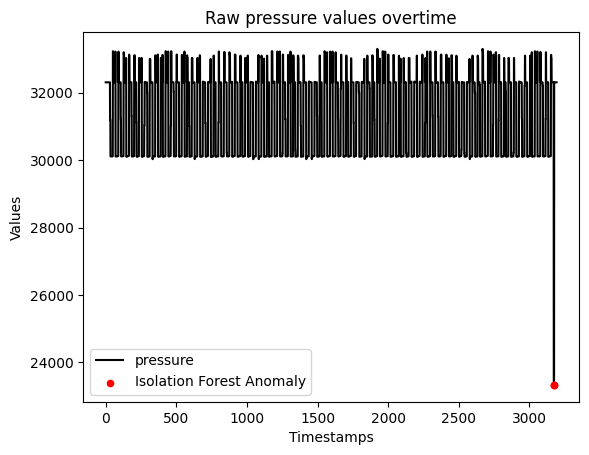

In [4]:
plot_anomalies_scatter(pressure_df, pressure_iforest[0], label='Isolation Forest Anomaly')

Anomalies detected: 3


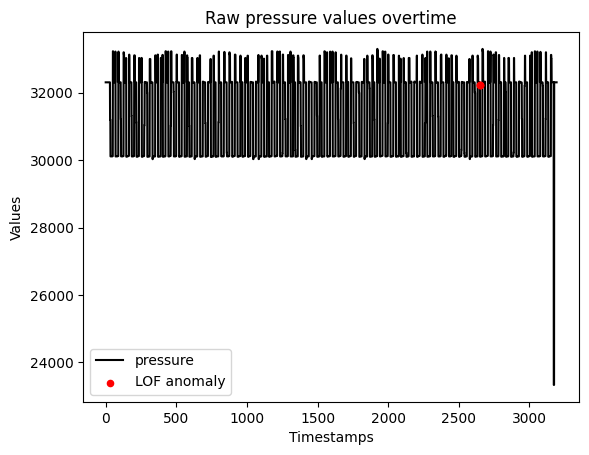

In [5]:
plot_anomalies_scatter(pressure_df, pressure_lof[0], label='LOF anomaly')

Anomalies detected: 4


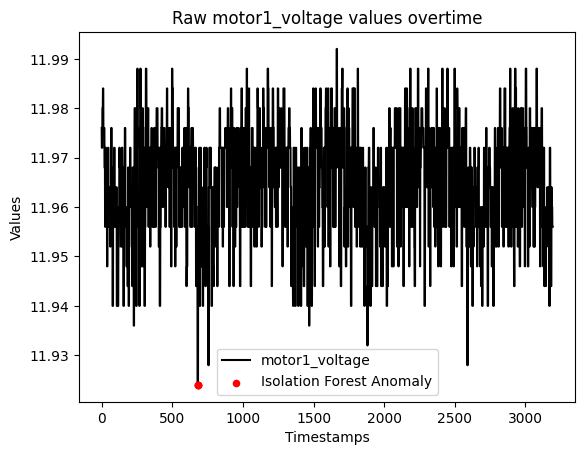

In [6]:
plot_anomalies_scatter(voltage_df, voltage_iforest[0], label='Isolation Forest Anomaly')

Anomalies detected: 3


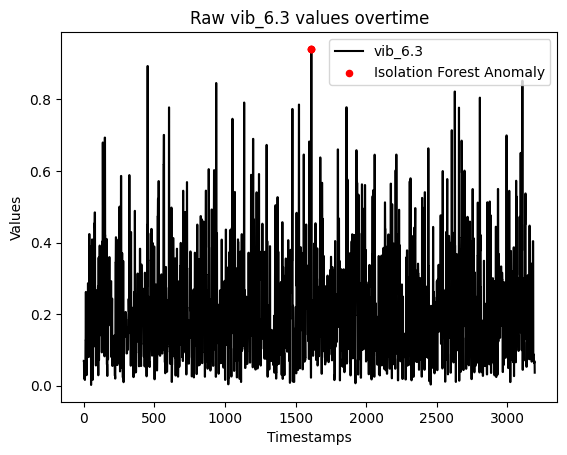

In [7]:
plot_anomalies_scatter(vibration_df, vibration_iforest[0], label='Isolation Forest Anomaly')

Anomalies detected: 4


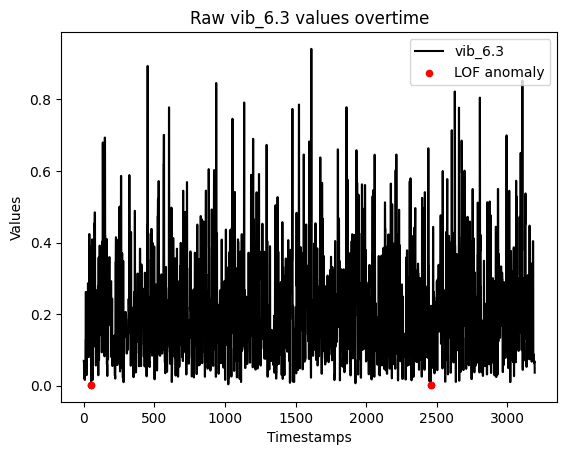

In [8]:
plot_anomalies_scatter(vibration_df, vibration_lof[0], label='LOF anomaly')

Anomalies detected: 3


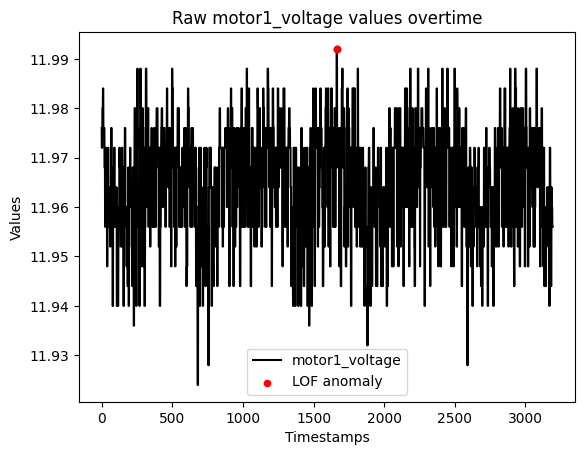

In [9]:
plot_anomalies_scatter(voltage_df, voltage_lof[0], label='LOF anomaly')